# PHASE 1
# PREPROCESSING EXPERIMENTS FOR BraTS2021
# Impact of Normalization and Tumor-Focused Sampling

This notebook compares three preprocessing pipelines for brain tumor segmentation with a SwinUNETR model on BraTS2021, to select the best configuration for full fine-tuning (Phase 2). Performance is measured by Dice (DSC) and the 95th-percentile Hausdorff Distance (HD95).

The pipelines compared:
- **Baseline** - standard normalization, random flips, intensity jitter.
- **Intensity Normalization** - percentile-based intensity clipping.
- **Tumor-Focused Sampling** - tumor-focused cropping (`RandCropByPosNegLabeld`).

## Overview

This notebook proceeds in three stages:

1. **Cohort setup**: `n_cohorts` independent cohorts (A, B, C by default) of `n_cohort` patients each (100 by default) are drawn from the training pool, to assess robustness across samples.
2. **Experiments**: each preprocessing pipeline is trained on every cohort, and per-subregion DSC and HD95 (TC, WT, ET) are tracked across epochs.
3. **Comparison**: the pipelines are compared on stability and accuracy, and the best configuration is selected for Phase 2.

All configurable parameters (paths, `n_cohort`, `n_cohorts`, `n_val`, `roi_size`, `max_epochs`, `val_every`, `lr`, `overlap`) are **centralised in the configuration cell** at the top. The values used here are one instance of the design, not fixed requirements.

Input channel order is **[FLAIR, T1ce, T1, T2]**. Output channel order is **[TC, WT, ET]**.

## 1. Environment setup and library versions

Import required libraries and display their versions along with CUDA availability and GPU information for reproducibility.

In [1]:
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import nibabel 
import einops
import tqdm
import numpy 
import os
import json
import random
import re

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import monai
from monai.data import Dataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.metrics import HausdorffDistanceMetric
from monai.utils.enums import MetricReduction
from monai.inferers import sliding_window_inference
from monai.transforms import (
    SpatialPadd,
    LoadImaged,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd,
    RandSpatialCropd,
    RandCropByPosNegLabeld,
    RandFlipd,
    NormalizeIntensityd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    ScaleIntensityRangePercentilesd,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
)

print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)
print("nibabel:", nibabel.__version__)
print("einops:", einops.__version__)
print("tqdm:", tqdm.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)

PyTorch: 2.12.0.dev20260408+cu128
MONAI: 1.5.2
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM (GB): 17.102864384
nibabel: 5.4.2
einops: 0.4.1
tqdm: 4.59.0
numpy: 1.26.4
matplotlib: 3.10.9


## 2. Set up file paths and output folders

Define paths for the data directory, the JSON file containing fold splits, the pretrained model, the output directory and the masks directory for inference.
All output folders are created if they do not already exist.

In [ ]:
# Central configuration
# To re-run the experiment under different settings, edit only this cell.
# Defaults (100 x 3, 50 val) were chosen for a robustness comparison, not final performance.

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

# Paths
# NOTE: data_dir must be the folder containing TrainingData/, because the JSON paths are prefixed
# with "TrainingData/..." (joined onto data_dir in build_file_list).
# Input channel order throughout is [FLAIR, T1ce, T1, T2]; output channels are [TC, WT, ET].
data_dir = os.path.join(project_root, "data", "BraTS21", "BraTS2021_Training_Data")
json_dir = os.path.join(project_root, "jsons")
json_path = os.path.join(json_dir, "brats21_folds.json")
pretrained_path = os.path.join(project_root, "pretrained_models", "model_fold1", "model.pt")
output_dir = os.path.join(project_root, "outputs", "outputs_preprocessing_experiments")

os.makedirs(json_dir, exist_ok=True)  
os.makedirs(output_dir, exist_ok=True)

# Data split
val_fold = 1   # fold held out for validation; all other folds are used for training
n_val = 50   # number of validation patients (subset of the val_fold pool)
n_cohort = 100   # patients per cohort (3 cohorts: A, B, C)
n_cohorts = 3   # number of cohorts
n_hist_check = 10   # number of validation patients inspected in the percentile-clipping histograms

# Training settings
roi_size = (128, 128, 128)   # sliding-window/crop size
batch_size = 1
max_epochs = 80
val_every = 10  # run validation every `val_every` epochs
lr = 1e-4
overlap = 0.5   # sliding-window inference overlap
sw_batch_size = 1  # sliding-window inference batch size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Project root: {project_root}")
print(f"Output dir: {output_dir}")
print(f"Data dir exists: {os.path.exists(data_dir)}")
print(f"JSON folds exist: {os.path.exists(json_path)}")
print(f"Pretrained model exists: {os.path.exists(pretrained_path)}")


## 3. Load the fold splits and separate validation from training

Patients whose fold equals val_fold (set in the configuration cell) are held out as the validation set, all remaining folds form the training set. Exact patient counts follow from the fold definitions in the splits JSON.

In [ ]:
# Load the JSON file containing the 5‑fold split information.
with open(json_path, "r") as f:
    splits = json.load(f)

# Separate validation from the training
all_training = splits["training"]
train_cases = [case for case in all_training if case["fold"] != val_fold]
val_cases = [case for case in all_training if case["fold"] == val_fold]

print(f"Total: {len(all_training)} | "
      f"Train (folds != {val_fold}): {len(train_cases)} | "
      f"Val (fold {val_fold}): {len(val_cases)}")

assert len(train_cases) >= n_cohorts * n_cohort, \
    f"Not enough training patients ({len(train_cases)}) for {n_cohorts} cohorts of {n_cohort}"
assert len(val_cases) >= n_val, \
    f"Not enough validation patients ({len(val_cases)}) for n_val={n_val}"

## 4. Generate or load cohorts A, B, C

Shuffle the training pool and take the first n_cohort patients per cohort (100 by default), saving each as a JSON file. On later runs the existing cohorts are loaded from those files and an overlap check confirms no patient appears in more than one cohort.

In [ ]:
paths = {
    "A": os.path.join(json_dir, "cohort_A.json"),
    "B": os.path.join(json_dir, "cohort_B.json"),
    "C": os.path.join(json_dir, "cohort_C.json"),
}

if all(os.path.exists(p) for p in paths.values()):
    with open(paths["A"]) as f: cohort_A = json.load(f)
    with open(paths["B"]) as f: cohort_B = json.load(f)
    with open(paths["C"]) as f: cohort_C = json.load(f)
    print("Existing cohorts were loaded.")
else:
    rng = random.Random(42)
    shuffled = train_cases[:]
    rng.shuffle(shuffled)
    cohort_A = shuffled[0 * n_cohort : 1 * n_cohort]
    cohort_B = shuffled[1 * n_cohort : 2 * n_cohort]
    cohort_C = shuffled[2 * n_cohort : 3 * n_cohort]
    for name, cohort in zip("ABC", (cohort_A, cohort_B, cohort_C)):
        with open(paths[name], "w") as f:
            json.dump(cohort, f, indent=2)
    print("New cohorts were generated.")

print(f"Cohort A: {len(cohort_A)} patients")
print(f"Cohort B: {len(cohort_B)} patients")
print(f"Cohort C: {len(cohort_C)} patients")

# Overlap check
ids_A = {c["image"][0] for c in cohort_A}
ids_B = {c["image"][0] for c in cohort_B}
ids_C = {c["image"][0] for c in cohort_C}
print(f"A∩B: {len(ids_A & ids_B)}")
print(f"A∩C: {len(ids_A & ids_C)}")
print(f"B∩C: {len(ids_B & ids_C)}")

## 5. Create the validation file list

Build a list of dictionaries with full paths to the four MRI modalities (FLAIR, T1ce, T1, T2) and the segmentation mask for each of the 50 validation patients, and verify the first entry's files exist. The per-cohort training file lists are built later, when each experiment is run.

In [ ]:
def build_file_list(cohort, data_dir):
    data_list = []
    for case in cohort:
        data_list.append({
            "image": [
                os.path.join(data_dir, case["image"][0]), # channel 0 = FLAIR
                os.path.join(data_dir, case["image"][1]), # channel 1 = T1ce
                os.path.join(data_dir, case["image"][2]), # channel 2 = T1
                os.path.join(data_dir, case["image"][3]), # channel 3 = T2
            ],
            "label": os.path.join(data_dir, case["label"])
        })
    return data_list

# Build the validation file list (full paths to the 4 modalities + mask).
# The per-cohort training lists are built later, when each experiment runs.

val_files = build_file_list(val_cases[:n_val], data_dir)

# Verify first entry
print("First validation entry:")
print("image[0]:", val_files[0]["image"][0])
print("label:", val_files[0]["label"])

print(f"Validation patients: {len(val_files)}")
print(f"\nFile exists check:")
print(f"Image exists: {os.path.exists(val_files[0]['image'][0])}")
print(f"Label exists: {os.path.exists(val_files[0]['label'])}")

## 6. Inspect a sample image and its label

Load one patient’s FLAIR image and segmentation mask, print their shapes and display a central slice to confirm correct loading and label values.

In [ ]:
# Inspect one sample (FLAIR + segmentation) chosen generically from the file lists.

sample = val_files[0]
img_add = sample["image"][0]   # channel 0 = FLAIR
label_add = sample["label"]
pid = os.path.basename(os.path.dirname(label_add))

print(f"Sample patient: {pid}")
print(f"Image exists: {os.path.exists(img_add)}")
print(f"Label exists: {os.path.exists(label_add)}")

img = nibabel.load(img_add).get_fdata()
label = nibabel.load(label_add).get_fdata()
print(f"Image shape: {img.shape}, Label shape: {label.shape}")
print(f"Unique label values: {numpy.unique(label)}")

mid = img.shape[2] // 2   # generic mid-axial slice
plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)
plt.title(f"FLAIR image (slice {mid})")
plt.imshow(img[:, :, mid], cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title(f"Segmentation mask (slice {mid})")
plt.imshow(label[:, :, mid])
plt.axis("off")
plt.savefig(os.path.join(output_dir, "sample_image_label.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Validation transforms

Compose a fixed MONAI transform pipeline for validation: load the four modality images, ensure channel-first ordering, convert the segmentation label to three binary channels (TC, WT, ET) using `ConvertToMultiChannelBasedOnBratsClassesd`, apply channel-wise intensity normalization on non-zero voxels and convert to PyTorch tensors. No augmentation is applied.

In [ ]:
# Validation transforms (fixed for the experiments E0, E1, E2 (and E3))
val_transforms = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),    # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            EnsureTyped(keys=["image", "label"]),
        ]
    )

print("Validation transforms were defined.")

The three pipelines compared here (baseline, intensity normalisation, tumour-focused sampling) were chosen for this study. However, the structure is extensible. Additional preprocessing strategies can be added by defining a new training-transform pipeline and appending it to the experiment loop.

## 8. Training transforms

In this block, three separate training transform pipelines are defined. All three share the same core operations (loading, channel conversion, random flips on all axes, intensity normalization, padding to 128³, intensity scaling/shifting and conversion to tensors). They differ in two key aspects: intensity normalization and patch-sampling strategy.

### E0 - Baseline

* Replicates the standard MONAI preprocessing pipeline.
* No percentile clipping.
* Uses `CropForegroundd` followed by `RandSpatialCropd` to crop a 128³ region from the foreground.

### E1 - Intensity Normalization

* Compared to Baseline, it adds `ScaleIntensityRangePercentilesd` before `NormalizeIntensityd`.
* Percentiles: lower=0.5, upper=99.99, mapping to [0,1].

### E2 - Tumor Sampling

* Compared to Baseline, it replaces the foreground crop (`CropForegroundd` + `RandSpatialCropd`) with `RandCropByPosNegLabeld`.
* Positive:negative ratio = 3:1, focusing crops on tumor regions.

### These three pipelines correspond to experiments:

* Exp0_Baseline
* Exp1_IntensityNorm
* Exp2_TumorSampling

In [ ]:
# Experiment E0 (baseline)
train_transforms_E0 = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),  # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            CropForegroundd(
                keys=["image", "label"],
                source_key="image",
            ),
            RandSpatialCropd(
                keys=["image", "label"],
                roi_size=roi_size,
                random_size=False,
            ),
            SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
            EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
        ]
    )

print("First training transform pipeline was defined.")

# Experiment E1 (intensity normalization)
train_transforms_E1 = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),    # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            CropForegroundd(
                keys=["image", "label"],
                source_key="image",
            ),
            RandSpatialCropd(
                keys=["image", "label"],
                roi_size=roi_size,
                random_size=False,
            ),
            SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            ScaleIntensityRangePercentilesd(
                keys="image", 
                lower=0.5, 
                upper=99.99, 
                b_min=0.0, 
                b_max=1.0, 
                clip=True,
            ),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
            EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
        ]
    )

print("Second training transform pipeline was defined.")

# Experiment E2 (tumor focused sampling)
train_transforms_E2 = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),   # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            RandCropByPosNegLabeld(
                keys=["image", "label"],
                label_key="label",
                spatial_size=roi_size,
                pos=3,
                neg=1,
                num_samples=1,
                image_key="image",
                image_threshold=0,
            ),
            SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
            EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
        ]
    )

print("Third training transform pipeline was defined.")

## 9. Function to build DataLoaders

Define a helper function that creates MONAI `Dataset` and `DataLoader` objects for training and validation. The training loader is shuffled, the validation loader is not. `pin_memory=True` is enabled to speed up CPU to GPU transfers.

In [ ]:
def get_dataloaders(train_transforms, train_files, val_files):
    train_ds = Dataset(data=train_files, transform=train_transforms)
    val_ds = Dataset(data=val_files, transform=val_transforms)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    return train_loader, val_loader

print("Data loader function was defined.")

## 10. Build and load the SwinUNETR model

Define a helper that builds the SwinUNETR architecture and loads a checkpoint. The same function is reused for both the pretrained starting point and the fine-tuned checkpoint. It accepts the three common checkpoint layouts (`state_dict`, `model` key or `raw state dict`) and loading is verified once on the pretrained checkpoint.

In [ ]:
# SwinUNETR builder and loader
# The architecture is defined for both the pretrained checkpoint and the fine-tuned checkpoint.

def build_swin_unetr(roi_size, device):
    """Construct the SwinUNETR used throughout this notebook."""
    model = SwinUNETR(
        img_size=roi_size,   # spatial size of the sliding-window ROI
        in_channels=4,   # FLAIR, T1ce, T1, T2
        out_channels=3,   # TC, WT, ET
        feature_size=48,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        dropout_path_rate=0.0,
        use_checkpoint=True,
    )
    return model.to(device)

def load_model(path, device, roi_size=roi_size):
    """Build the network and load a checkpoint (pretrained or fine-tuned).
    Handles the three checkpoint layouts encountered: a raw state_dict or a dict wrapped under 'state_dict' or 'model'.
    """
    model = build_swin_unetr(roi_size, device)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    elif "model" in ckpt:
        model.load_state_dict(ckpt["model"])
    else:
        model.load_state_dict(ckpt)
    return model

# Quick load test of the pretrained checkpoint (free memory immediately after).
_test = load_model(pretrained_path, device)
del _test
if device.type == "cuda":
    torch.cuda.empty_cache()
print("Unified load_model() is OK - pretrained checkpoint loads correctly.")


## 11. Training and evaluation loop

Implement `run_experiment`, which trains for `max_epochs` epochs and evaluates every `val_every` epochs. It tracks per-subregion DSC and HD95 (TC, WT, ET), saves the best checkpoint by mean DSC, and returns the full training history and best mean DSC. The epoch-0 baseline (validating the pretrained model before fine-tuning) is disabled for this analysis but can be re-enabled in the loop.

In [ ]:
def run_experiment(exp_name, train_transforms, train_files, val_files, pretrained_path, device):
    print(f"\nStarting {exp_name} ...\n")

    # New model for each experiment
    model = load_model(pretrained_path, device)   # unified loader (pretrained start point)

    # Data loaders
    train_loader, val_loader = get_dataloaders(train_transforms, train_files, val_files)

    # Loss, optimizer, scheduler
    loss_fn = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs)

    # Metrics
    dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
    hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)
    
    best_mean_dice = 0
    history = {
        "train_loss": [],
        "val_dice_mean": [],
        "val_dice_tc": [],
        "val_dice_wt": [],
        "val_dice_et": [],
        "val_hd95_mean": [],
        "val_hd95_tc": [],
        "val_hd95_wt": [],
        "val_hd95_et": [],
    }

    # Epoch loop. Epoch 0 = pre-fine-tuning baseline, training starts at epoch 1.
    for epoch in range(0, max_epochs + 1):
        # Training
        if epoch > 0:  
            model.train()
            epoch_loss = 0

            for batch in train_loader:
                images = batch["image"].to(device)
                labels = batch["label"].to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            avg_loss = epoch_loss / len(train_loader)
            history["train_loss"].append(avg_loss)
            scheduler.step()
            print(f"Epoch {epoch}/{max_epochs} | Train Loss: {avg_loss:.4f}")

        # Validation runs every `val_every` epochs. The epoch-0 baseline (validating the pretrained model before 
        # any fine-tuning) is OFF for this analysis.
        # To switch it back ON, use the commented line instead of the active one:
        # if epoch == 0 or epoch % val_every == 0:   # <-- epoch-0 baseline ON
        if epoch > 0 and epoch % val_every == 0:     # epoch-0 baseline OFF
            model.eval()
            with torch.no_grad():
                for val_batch in val_loader:
                    val_images = val_batch["image"].to(device)
                    val_labels = val_batch["label"].to(device)
                    val_outputs = sliding_window_inference(val_images, roi_size, sw_batch_size=sw_batch_size, predictor=model, overlap=overlap)
                    val_outputs = (torch.sigmoid(val_outputs) > 0.5).float()
                    dice_metric(y_pred=val_outputs, y=val_labels)
                    hd95_metric(y_pred=val_outputs, y=val_labels)

                dice_scores = dice_metric.aggregate()
                dice_metric.reset()

                hd95_scores, _ = hd95_metric.aggregate()
                hd95_metric.reset()
                hd95_scores = torch.nan_to_num(hd95_scores, nan=0.0, posinf=0.0)

                # channel 0 = TC, channel 1 = WT, channel 2 = ET
                tc_dice, wt_dice, et_dice = dice_scores[0].item(), dice_scores[1].item(), dice_scores[2].item()
                mean_dice = (tc_dice + wt_dice + et_dice) / 3
                tc_hd95, wt_hd95, et_hd95 = hd95_scores[0].item(), hd95_scores[1].item(), hd95_scores[2].item()
                mean_hd95 = (tc_hd95 + wt_hd95 + et_hd95) / 3

                history["val_dice_mean"].append(mean_dice)
                history["val_dice_tc"].append(tc_dice)
                history["val_dice_wt"].append(wt_dice)
                history["val_dice_et"].append(et_dice)
                history["val_hd95_mean"].append(mean_hd95)
                history["val_hd95_tc"].append(tc_hd95)
                history["val_hd95_wt"].append(wt_hd95)
                history["val_hd95_et"].append(et_hd95)

                print(f"  Val DSC  -> TC: {tc_dice:.4f} | WT: {wt_dice:.4f} | ET: {et_dice:.4f} | Mean: {mean_dice:.4f}")
                print(f"  Val HD95 -> TC: {tc_hd95:.2f} | WT: {wt_hd95:.2f} | ET: {et_hd95:.2f} | Mean: {mean_hd95:.2f}")

                if mean_dice > best_mean_dice:
                    best_mean_dice = mean_dice
                    torch.save(model.state_dict(),
                               os.path.join(output_dir, f"{exp_name}_best_model.pt"))
                    print(f" New best model saved at epoch {epoch} (Mean DSC: {mean_dice:.4f})")

    print(f"\n{exp_name} completed. Best mean DSC: {best_mean_dice:.4f}\n")
    return history, best_mean_dice

print("Training loop was defined.")


## 12. Run experiments on all three cohorts (A, B, C)

Run the three preprocessing pipelines (`Baseline`, `IntensityNorm`, `TumorSampling`) on each cohort, giving n_cohorts × 3 runs in total. All runs use the same training loop and the same fixed validation set, so any difference in results reflects the preprocessing method and the cohort sample rather than the evaluation setup.

Results are collected into a single dictionary `results`, keyed by cohort (`results["A"]`, `results["B"]`, `results["C"]`) for aggregation and plotting.

In [ ]:
cohort_inputs = {"A": cohort_A, "B": cohort_B, "C": cohort_C}
results = {}

for cohort_id, cohort_list in cohort_inputs.items():
    print(f"\nStarting Cohort {cohort_id}\n")
    train_files = build_file_list(cohort_list, data_dir)
    cohort_results = {}
    for exp_name, transforms in [
        ("Exp0_Baseline", train_transforms_E0),
        ("Exp1_IntensityNorm", train_transforms_E1),
        ("Exp2_TumorSampling", train_transforms_E2),
    ]:
        history, best_dice = run_experiment(
            f"Cohort{cohort_id}_{exp_name}", transforms,
            train_files, val_files, pretrained_path, device
        )
        cohort_results[exp_name] = {"best_mean_dice": best_dice, "history": history}
    results[cohort_id] = cohort_results
    print(f"\nCohort {cohort_id} completed.\n")


## 13. Visualise training loss, mean DSC and mean HD95 for each cohort

For each cohort generates three diagnostic plots, arranged left to right:

1. **Training loss curves** over epochs for the three preprocessing methods. Shows how quickly each pipeline converges and whether training is stable.
2. **Validation mean DSC** at every validation epoch. This is the primary selection metric (the best model is saved on highest mean DSC).
3. **Validation mean HD95 (mm)** at every validation epoch. Complements DSC by capturing boundary delineation quality.

At the end,for each experiment the best mean DSC achieved on that cohort together with the mean HD95 at that same (best-DSC) epoch are printed.


In [ ]:
cohorts = {
    "Cohort A": results["A"],
    "Cohort B": results["B"],
    "Cohort C": results["C"],
}

exp_names = ["Exp0_Baseline", "Exp1_IntensityNorm", "Exp2_TumorSampling"]
n_val_points = len(next(iter(results["A"].values()))["history"]["val_dice_mean"])
# Validation epochs (epoch-0 baseline OFF). If you re-enable epoch-0 validation in run_experiment, 
# use instead: val_epochs = [0] + list(range(val_every, max_epochs + 1, val_every))
val_epochs = (list(range(val_every, max_epochs + 1, val_every)))[:n_val_points]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

for row, (cohort_name, cohort_results) in enumerate(cohorts.items()):
    ax_loss, ax_dice, ax_hd95 = axes[row]

    # Column 1: training loss (per epoch)
    train_epochs = range(1, max_epochs + 1)
    for exp_name in exp_names:
        ax_loss.plot(train_epochs, cohort_results[exp_name]["history"]["train_loss"], label=exp_name)
    ax_loss.set_title(f"{cohort_name} - Training Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Dice loss")
    ax_loss.legend()

    # Column 2: validation mean DSC
    for exp_name in exp_names:
        ax_dice.plot(val_epochs, cohort_results[exp_name]["history"]["val_dice_mean"],
                     marker='o', label=exp_name)
    ax_dice.set_title(f"{cohort_name} - Val Mean DSC")
    ax_dice.set_xlabel("Epoch")
    ax_dice.set_ylabel("DSC")
    ax_dice.legend()

    # Column 3: validation mean HD95
    for exp_name in exp_names:
        ax_hd95.plot(val_epochs, cohort_results[exp_name]["history"]["val_hd95_mean"],
                     marker='o', label=exp_name)
    ax_hd95.set_title(f"{cohort_name} - Val Mean HD95")
    ax_hd95.set_xlabel("Epoch")
    ax_hd95.set_ylabel("HD95 (mm)")
    ax_hd95.legend()

plt.tight_layout()
plot_path = os.path.join(output_dir, "preprocessing_experiments_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

# Best mean DSC per cohort/experiment with HD95 at that same (best-DSC) epoch
for cohort_name, cohort_results in cohorts.items():
    print(f"\n{cohort_name}")
    for exp, data in cohort_results.items():
        hist = data["history"]
        best_idx = int(numpy.argmax(hist["val_dice_mean"]))
        best_hd95 = hist["val_hd95_mean"][best_idx]
        print(f"  {exp}: DSC={data['best_mean_dice']:.4f} | HD95={best_hd95:.2f} mm")

## 14. Collect and summarise performance across cohorts

For each experiment, it summarises mean DSC and mean HD95 over the three cohorts under three views: the best score reached at any validation epoch, the final-epoch score (epoch 80) and the mean across all validation epochs. Each is reported as the average ± standard deviation across cohorts A, B and C. The winning experiment is identified under each view (highest mean DSC, lowest mean HD95).

Six formatted tables are printed: best / final / mean-across-epochs for DSC and for HD95 each showing the per-cohort values alongside the cross-cohort mean and standard deviation, followed by the winners under each criterion.

In [ ]:
# Collect results
experiments = ["Exp0_Baseline", "Exp1_IntensityNorm", "Exp2_TumorSampling"]
summary_stats = {}

results_A = results["A"]
results_B = results["B"]
results_C = results["C"]

for exp in experiments:
    # Best DSC
    score_A = results_A[exp]["best_mean_dice"]
    score_B = results_B[exp]["best_mean_dice"]
    score_C = results_C[exp]["best_mean_dice"]

    # Final epoch DSC
    final_dsc_A = results_A[exp]["history"]["val_dice_mean"][-1]
    final_dsc_B = results_B[exp]["history"]["val_dice_mean"][-1]
    final_dsc_C = results_C[exp]["history"]["val_dice_mean"][-1]

    # Mean all epochs DSC
    mean_all_dsc_A = numpy.mean(results_A[exp]["history"]["val_dice_mean"])
    mean_all_dsc_B = numpy.mean(results_B[exp]["history"]["val_dice_mean"])
    mean_all_dsc_C = numpy.mean(results_C[exp]["history"]["val_dice_mean"])

    # Best HD95 (lowest)
    best_hd95_A = numpy.min(results_A[exp]["history"]["val_hd95_mean"])
    best_hd95_B = numpy.min(results_B[exp]["history"]["val_hd95_mean"])
    best_hd95_C = numpy.min(results_C[exp]["history"]["val_hd95_mean"])

    # Final epoch HD95
    final_hd95_A = results_A[exp]["history"]["val_hd95_mean"][-1]
    final_hd95_B = results_B[exp]["history"]["val_hd95_mean"][-1]
    final_hd95_C = results_C[exp]["history"]["val_hd95_mean"][-1]

    # Mean all epochs HD95
    mean_all_hd95_A = numpy.mean(results_A[exp]["history"]["val_hd95_mean"])
    mean_all_hd95_B = numpy.mean(results_B[exp]["history"]["val_hd95_mean"])
    mean_all_hd95_C = numpy.mean(results_C[exp]["history"]["val_hd95_mean"])

    summary_stats[exp] = {
        # Best DSC
        "cohort_A_best_dsc":    score_A,
        "cohort_B_best_dsc":    score_B,
        "cohort_C_best_dsc":    score_C,
        "mean_best_dsc":        numpy.mean([score_A, score_B, score_C]),
        "std_best_dsc":         numpy.std([score_A, score_B, score_C]),
        # Final epoch DSC
        "cohort_A_final_dsc":   final_dsc_A,
        "cohort_B_final_dsc":   final_dsc_B,
        "cohort_C_final_dsc":   final_dsc_C,
        "mean_final_dsc":       numpy.mean([final_dsc_A, final_dsc_B, final_dsc_C]),
        "std_final_dsc":        numpy.std([final_dsc_A, final_dsc_B, final_dsc_C]),
        # Mean all epochs DSC
        "cohort_A_mean_all_dsc": mean_all_dsc_A,
        "cohort_B_mean_all_dsc": mean_all_dsc_B,
        "cohort_C_mean_all_dsc": mean_all_dsc_C,
        "mean_all_dsc":         numpy.mean([mean_all_dsc_A, mean_all_dsc_B, mean_all_dsc_C]),
        "std_all_dsc":          numpy.std([mean_all_dsc_A, mean_all_dsc_B, mean_all_dsc_C]),
        # Best HD95
        "cohort_A_best_hd95":   best_hd95_A,
        "cohort_B_best_hd95":   best_hd95_B,
        "cohort_C_best_hd95":   best_hd95_C,
        "mean_best_hd95":       numpy.mean([best_hd95_A, best_hd95_B, best_hd95_C]),
        "std_best_hd95":        numpy.std([best_hd95_A, best_hd95_B, best_hd95_C]),
        # Final epoch HD95
        "cohort_A_final_hd95":  final_hd95_A,
        "cohort_B_final_hd95":  final_hd95_B,
        "cohort_C_final_hd95":  final_hd95_C,
        "mean_final_hd95":      numpy.mean([final_hd95_A, final_hd95_B, final_hd95_C]),
        "std_final_hd95":       numpy.std([final_hd95_A, final_hd95_B, final_hd95_C]),
        # Mean all epochs HD95
        "cohort_A_mean_all_hd95": mean_all_hd95_A,
        "cohort_B_mean_all_hd95": mean_all_hd95_B,
        "cohort_C_mean_all_hd95": mean_all_hd95_C,
        "mean_all_hd95":        numpy.mean([mean_all_hd95_A, mean_all_hd95_B, mean_all_hd95_C]),
        "std_all_hd95":         numpy.std([mean_all_hd95_A, mean_all_hd95_B, mean_all_hd95_C]),
    }

# Table 1 - Best DSC
print("\n" + "="*80)
print("TABLE 1: BEST MEAN DSC (highest score at any validation epoch)")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_best_dsc']:>10.4f} {data['cohort_B_best_dsc']:>10.4f} "
          f"{data['cohort_C_best_dsc']:>10.4f} {data['mean_best_dsc']:>10.4f} {data['std_best_dsc']:>8.4f}")

# Table 2 - Final epoch DSC
print("\n" + "="*80)
print("TABLE 2: FINAL EPOCH MEAN DSC (score at the last validation epoch)")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_final_dsc']:>10.4f} {data['cohort_B_final_dsc']:>10.4f} "
          f"{data['cohort_C_final_dsc']:>10.4f} {data['mean_final_dsc']:>10.4f} {data['std_final_dsc']:>8.4f}")

# Table 3 - Mean all epochs DSC
print("\n" + "="*80)
print("TABLE 3: MEAN DSC ACROSS ALL VALIDATION EPOCHS")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_mean_all_dsc']:>10.4f} {data['cohort_B_mean_all_dsc']:>10.4f} "
          f"{data['cohort_C_mean_all_dsc']:>10.4f} {data['mean_all_dsc']:>10.4f} {data['std_all_dsc']:>8.4f}")

# Table 4 - Best HD95
print("\n" + "="*80)
print("TABLE 4: BEST MEAN HD95 (lowest score at any validation epoch)")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_best_hd95']:>10.2f} {data['cohort_B_best_hd95']:>10.2f} "
          f"{data['cohort_C_best_hd95']:>10.2f} {data['mean_best_hd95']:>10.2f} {data['std_best_hd95']:>8.2f}")

# Table 5 - Final epoch HD95
print("\n" + "="*80)
print("TABLE 5: FINAL EPOCH MEAN HD95 (score at the last validation epoch)")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_final_hd95']:>10.2f} {data['cohort_B_final_hd95']:>10.2f} "
          f"{data['cohort_C_final_hd95']:>10.2f} {data['mean_final_hd95']:>10.2f} {data['std_final_hd95']:>8.2f}")

# Table 6 - Mean all epochs HD95
print("\n" + "="*80)
print("TABLE 6: MEAN HD95 ACROSS ALL VALIDATION EPOCHS")
print(f"{'Experiment':<25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("="*80)
for exp, data in summary_stats.items():
    print(f"{exp:<25} {data['cohort_A_mean_all_hd95']:>10.2f} {data['cohort_B_mean_all_hd95']:>10.2f} "
          f"{data['cohort_C_mean_all_hd95']:>10.2f} {data['mean_all_hd95']:>10.2f} {data['std_all_hd95']:>8.2f}")

# Find winners
winner_best_dsc  = max(summary_stats, key=lambda x: summary_stats[x]["mean_best_dsc"])
winner_final_dsc = max(summary_stats, key=lambda x: summary_stats[x]["mean_final_dsc"])
winner_all_dsc   = max(summary_stats, key=lambda x: summary_stats[x]["mean_all_dsc"])
winner_best_hd95 = min(summary_stats, key=lambda x: summary_stats[x]["mean_best_hd95"])
winner_final_hd95= min(summary_stats, key=lambda x: summary_stats[x]["mean_final_hd95"])
winner_all_hd95  = min(summary_stats, key=lambda x: summary_stats[x]["mean_all_hd95"])

print("\n" + "="*80)
print("WINNERS:")
print(f"Best DSC:            {winner_best_dsc} (Mean: {summary_stats[winner_best_dsc]['mean_best_dsc']:.4f} ± {summary_stats[winner_best_dsc]['std_best_dsc']:.4f})")
print(f"Final epoch DSC:     {winner_final_dsc} (Mean: {summary_stats[winner_final_dsc]['mean_final_dsc']:.4f} ± {summary_stats[winner_final_dsc]['std_final_dsc']:.4f})")
print(f"Mean all epochs DSC: {winner_all_dsc} (Mean: {summary_stats[winner_all_dsc]['mean_all_dsc']:.4f} ± {summary_stats[winner_all_dsc]['std_all_dsc']:.4f})")
print(f"Best HD95:           {winner_best_hd95} (Mean: {summary_stats[winner_best_hd95]['mean_best_hd95']:.2f} ± {summary_stats[winner_best_hd95]['std_best_hd95']:.2f} mm)")
print(f"Final epoch HD95:    {winner_final_hd95} (Mean: {summary_stats[winner_final_hd95]['mean_final_hd95']:.2f} ± {summary_stats[winner_final_hd95]['std_final_hd95']:.2f} mm)")
print(f"Mean all epochs HD95:{winner_all_hd95} (Mean: {summary_stats[winner_all_hd95]['mean_all_hd95']:.2f} ± {summary_stats[winner_all_hd95]['std_all_hd95']:.2f} mm)")
 


TABLE 1: BEST MEAN DSC (highest score at any validation epoch)
Experiment                  Cohort A   Cohort B   Cohort C       Mean      Std
Exp0_Baseline                 0.9247     0.9231     0.9216     0.9231   0.0013
Exp1_IntensityNorm            0.9249     0.9239     0.9214     0.9234   0.0015
Exp2_TumorSampling            0.9246     0.9233     0.9256     0.9245   0.0009

TABLE 2: FINAL EPOCH MEAN DSC (score at epoch 80)
Experiment                  Cohort A   Cohort B   Cohort C       Mean      Std
Exp0_Baseline                 0.9233     0.9220     0.9195     0.9216   0.0016
Exp1_IntensityNorm            0.9240     0.9218     0.9200     0.9219   0.0016
Exp2_TumorSampling            0.9238     0.9219     0.9253     0.9237   0.0014

TABLE 3: MEAN DSC ACROSS ALL VALIDATION EPOCHS
Experiment                  Cohort A   Cohort B   Cohort C       Mean      Std
Exp0_Baseline                 0.9232     0.9222     0.9198     0.9217   0.0014
Exp1_IntensityNorm            0.9236     0.9224

## 15. Save results to disk

All results are saved to the output directory:
- a **JSON** file with the per-experiment statistics and the winners,
- a **summary CSV** (one row per experiment),
- a **validation-history CSV** with the full per-epoch curves for all 9 runs, including the per-region (WT, TC, ET) DSC and HD95,
- a **training-loss CSV** with the per-epoch loss for all 9 runs.

In [ ]:
summary_json = {
    exp: {k: float(v) for k, v in data.items()}
    for exp, data in summary_stats.items()
}
summary_json["winner_best_dsc"] = winner_best_dsc
summary_json["winner_final_dsc"] = winner_final_dsc
summary_json["winner_all_dsc"] = winner_all_dsc
summary_json["winner_best_hd95"] = winner_best_hd95
summary_json["winner_final_hd95"] = winner_final_hd95
summary_json["winner_all_hd95"] = winner_all_hd95

results_path = os.path.join(output_dir, "results_preprocessing_experiments.json")
with open(results_path, "w") as f:
    json.dump(summary_json, f, indent=2)

print("\nResults were saved.")

# 1) Flat summary table - one row per experiment (mirrors best_metrics.csv)
summary_df = pd.DataFrame.from_dict(summary_stats, orient="index")
summary_df.index.name = "experiment"
summary_df.to_csv(os.path.join(output_dir, "summary_preprocessing_experiments.csv"))

# 2) Full per-epoch histories for all 9 runs - so curves can be re-plotted without retraining
# Validation epochs (epoch-0 baseline OFF). If you re-enable epoch-0 validation in run_experiment, 
# use instead: val_epochs = [0] + list(range(val_every, max_epochs + 1, val_every))
val_epochs = list(range(val_every, max_epochs + 1, val_every))
train_epochs = list(range(1, max_epochs + 1))

val_rows, loss_rows = [], []
for cohort_id in ["A", "B", "C"]:
    for exp in experiments:
        hist = results[cohort_id][exp]["history"]

        # validation metrics: one row per validation epoch
        for i, ep in enumerate(val_epochs):
            val_rows.append({
                "cohort": cohort_id, "experiment": exp, "epoch": ep,
                "val_dice_mean": hist["val_dice_mean"][i],
                "val_dice_tc":   hist["val_dice_tc"][i],
                "val_dice_wt":   hist["val_dice_wt"][i],
                "val_dice_et":   hist["val_dice_et"][i],
                "val_hd95_mean": hist["val_hd95_mean"][i],
                "val_hd95_tc":   hist["val_hd95_tc"][i],
                "val_hd95_wt":   hist["val_hd95_wt"][i],
                "val_hd95_et":   hist["val_hd95_et"][i],
            })

        # training loss: one row per training epoch
        for i, ep in enumerate(train_epochs):
            loss_rows.append({
                "cohort": cohort_id, "experiment": exp, "epoch": ep,
                "train_loss": hist["train_loss"][i],
            })

pd.DataFrame(val_rows).to_csv(
    os.path.join(output_dir, "val_history_preprocessing_experiments.csv"), index=False)
pd.DataFrame(loss_rows).to_csv(
    os.path.join(output_dir, "train_loss_preprocessing_experiments.csv"), index=False)

print("CSVs saved - summary, val_history, train_loss")

In [ ]:
for cohort_id in ["A", "B", "C"]:
    for exp in experiments:
        h = results[cohort_id][exp]["history"]
        zeros = sum(v == 0.0 for v in h["val_hd95_tc"] + h["val_hd95_wt"] + h["val_hd95_et"])
        if zeros:
            print(f"{cohort_id} {exp}: {zeros} zero-HD95 values (substituted)")

##  16. Load saved results (optional - only when reopening the notebook)

In [ ]:
# OPTIONAL - run this only when reopening the notebook to restore results from disk without re-training. 
# If you have just run the training and save cells above, the in-memory variables are already correct 
# and this cell can be skipped.

# Summary stats + winners
with open(os.path.join(output_dir, "results_preprocessing_experiments.json")) as f:
    summary_json = json.load(f)

# Raw per-epoch histories
val_df = pd.read_csv(os.path.join(output_dir, "val_history_preprocessing_experiments.csv"))
loss_df = pd.read_csv(os.path.join(output_dir, "train_loss_preprocessing_experiments.csv"))

experiments = ["Exp0_Baseline", "Exp1_IntensityNorm", "Exp2_TumorSampling"]

results = {}
for cohort_id in ["A", "B", "C"]:
    results[cohort_id] = {}
    for exp in experiments:
        v = val_df[(val_df.cohort == cohort_id) & (val_df.experiment == exp)].sort_values("epoch")
        l = loss_df[(loss_df.cohort == cohort_id) & (loss_df.experiment == exp)].sort_values("epoch")
        history = {
            "train_loss":    l["train_loss"].tolist(),
            "val_dice_mean": v["val_dice_mean"].tolist(),
            "val_dice_tc":   v["val_dice_tc"].tolist(),
            "val_dice_wt":   v["val_dice_wt"].tolist(),
            "val_dice_et":   v["val_dice_et"].tolist(),
            "val_hd95_mean": v["val_hd95_mean"].tolist(),
            "val_hd95_tc":   v["val_hd95_tc"].tolist(),
            "val_hd95_wt":   v["val_hd95_wt"].tolist(),
            "val_hd95_et":   v["val_hd95_et"].tolist(),
        }
        best_dsc = summary_json[exp][f"cohort_{cohort_id}_best_dsc"]
        results[cohort_id][exp] = {"best_mean_dice": best_dsc, "history": history}

print("Results loaded - results reconstructed from CSVs.")
print(f"Cohorts: {list(results.keys())} | Experiments: {experiments}")

## 17. Aggregate comparison across cohorts (mean ± std)

This figure summarises the three preprocessing pipelines by combining their results across cohorts A, B and C into a single 3×3 grid:

- **Row 1 - Overview:** epoch-average training loss, validation mean DSC and validation mean HD95.
- **Row 2 - DSC by subregion:** WT, TC and ET.
- **Row 3 - HD95 by subregion:** WT, TC and ET.

For every panel except the training loss, the three cohorts are aggregated: each line is the mean across cohorts for a given pipeline, and the shaded band is ±1 standard deviation across cohorts. The training-loss panel plots all nine runs individually.

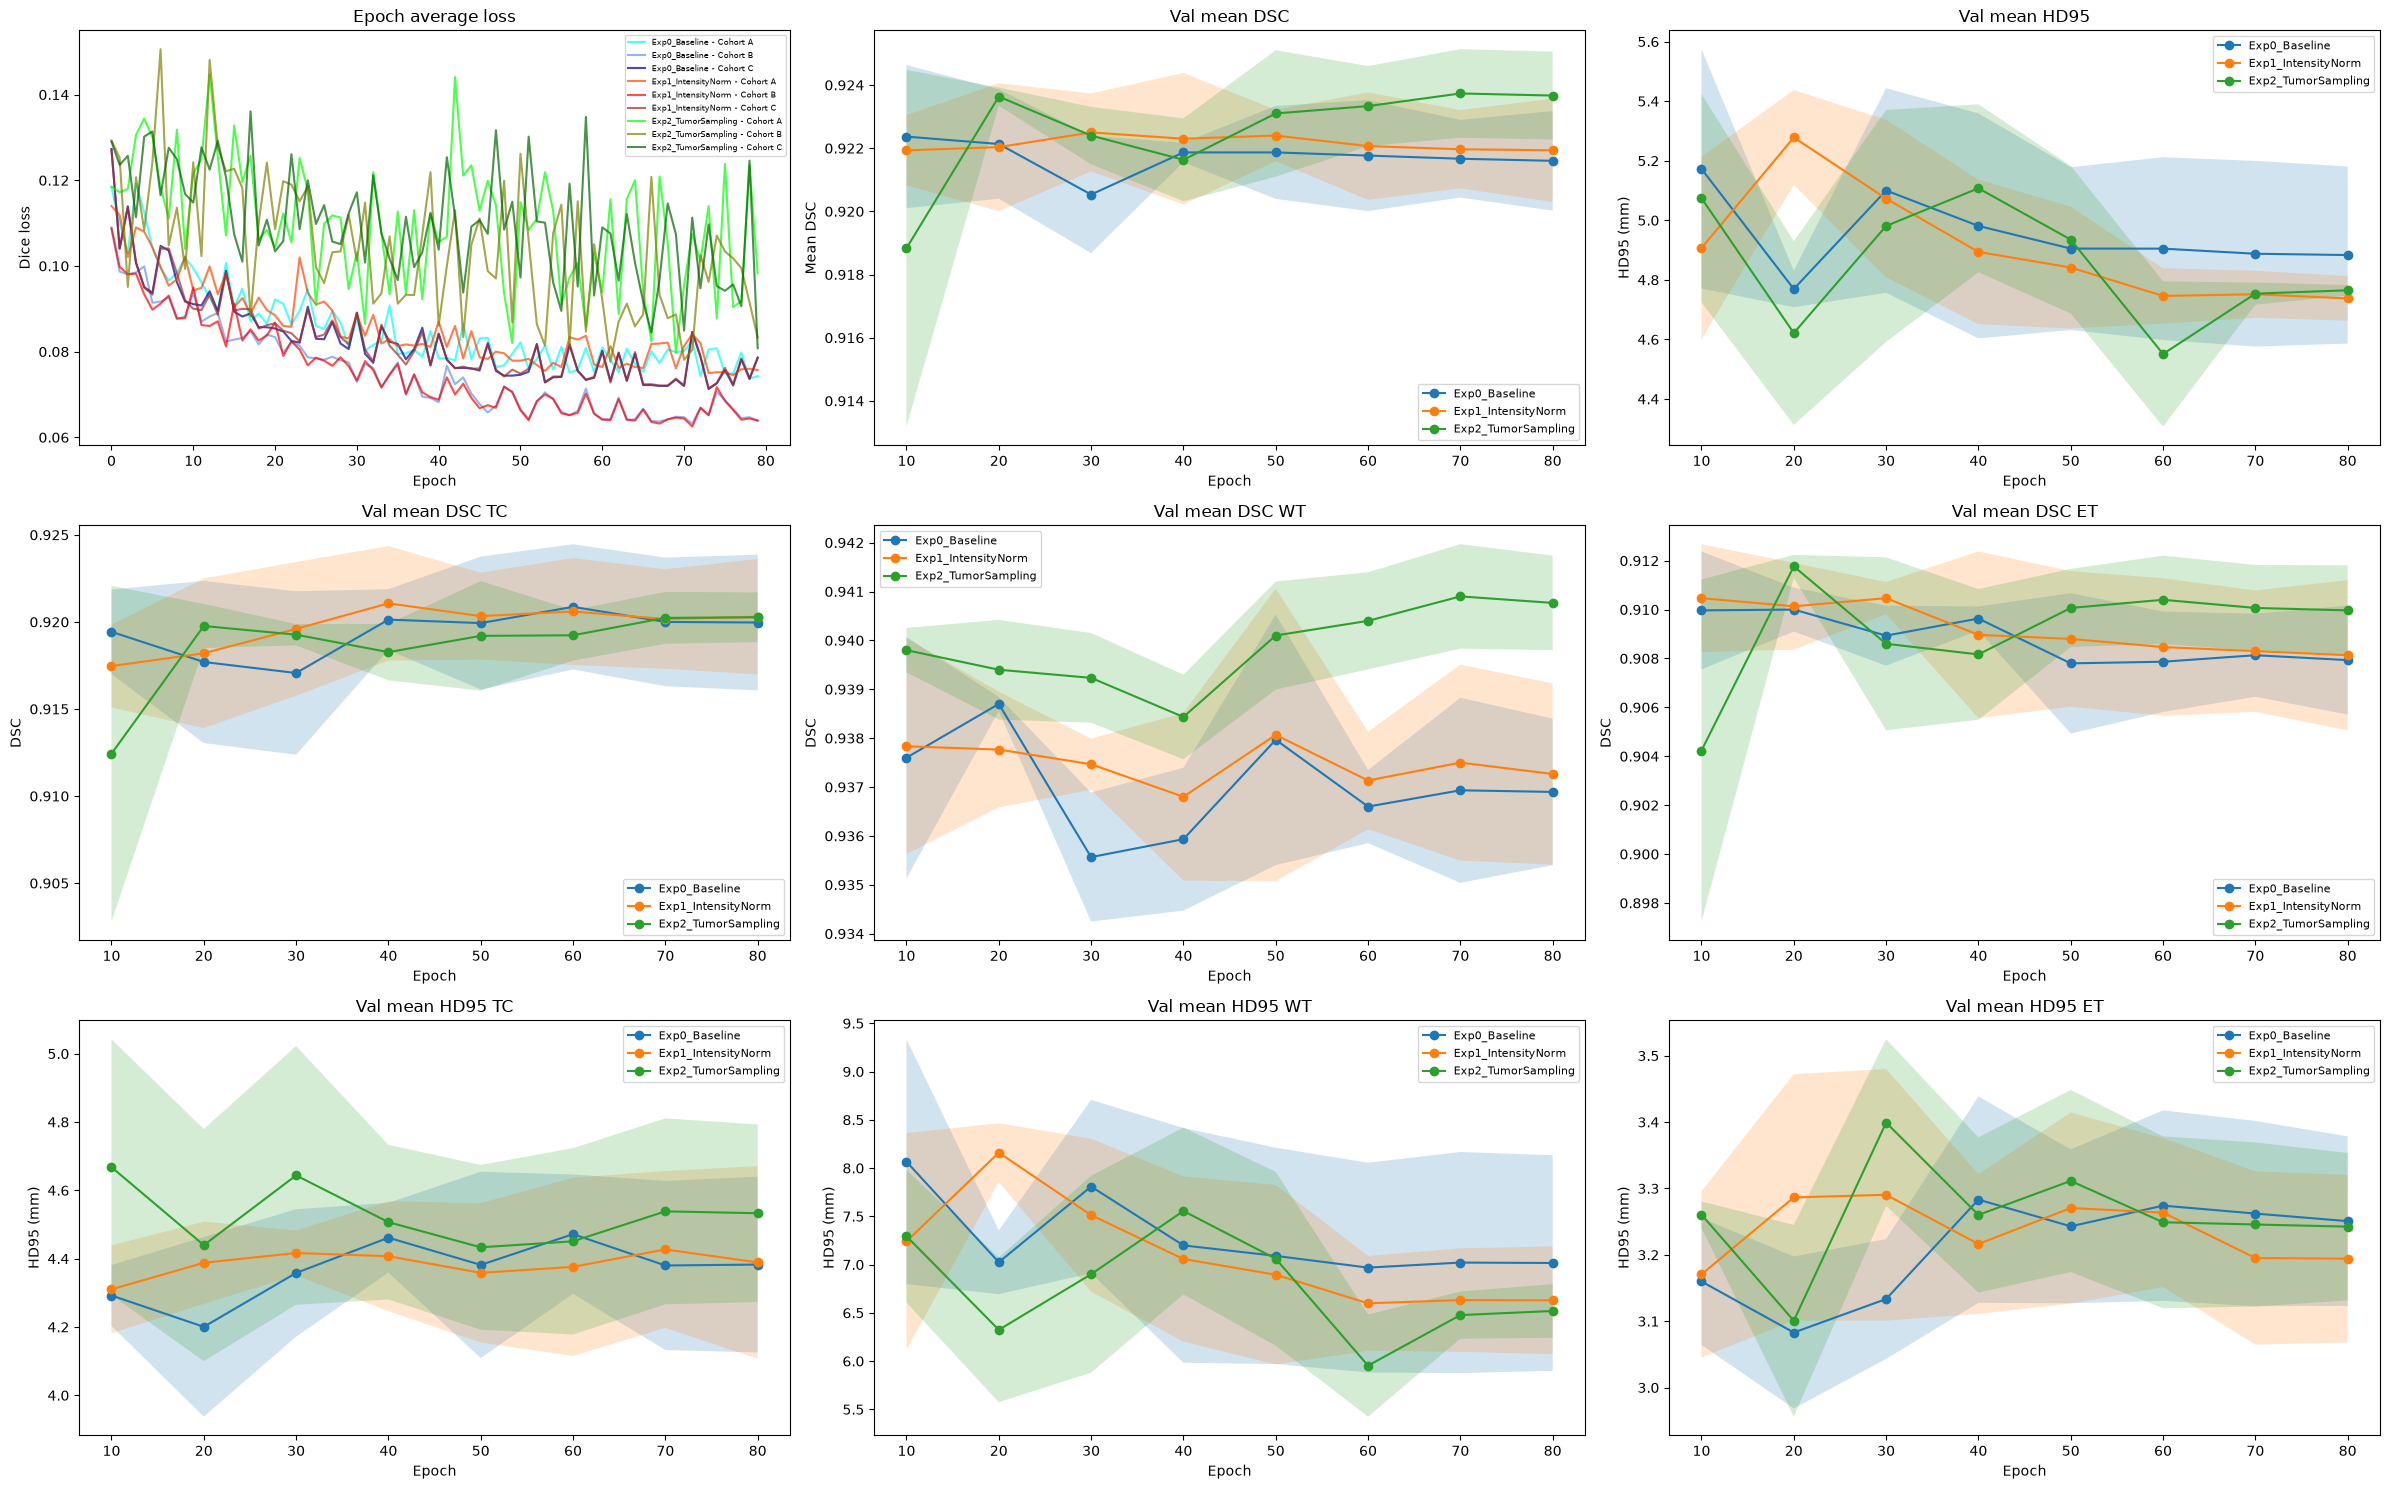

In [ ]:
# Validation epochs (epoch-0 baseline OFF). If you re-enable epoch-0 validation
# in run_experiment, use instead: val_epochs = [0] + list(range(val_every, max_epochs + 1, val_every))
val_epochs = list(range(val_every, max_epochs + 1, val_every))

colors = {
    "Exp0_Baseline":      {"A": "aqua", "B": "cornflowerblue", "C": "darkblue"},
    "Exp1_IntensityNorm": {"A": "orangered", "B": "red", "C": "brown"},
    "Exp2_TumorSampling": {"A": "lime", "B": "olive", "C": "darkgreen"},
}

fig, axes = plt.subplots(3, 3, figsize=(24, 15))

def plot_metric(ax, key, title, ylabel):
    """Mean ± std across cohorts A/B/C, one curve per experiment."""
    ax.set_title(title)
    for exp in experiments:
        scores_per_epoch = numpy.array([
            results_A[exp]["history"][key],
            results_B[exp]["history"][key],
            results_C[exp]["history"][key],
        ])
        mean_curve = numpy.mean(scores_per_epoch, axis=0)
        std_curve  = numpy.std(scores_per_epoch, axis=0)
        ax.plot(val_epochs, mean_curve, marker='o', label=exp)
        ax.fill_between(val_epochs, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, label="_nolegend_")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

# Row 1:

# Plot 1 - Training loss (per-cohort curves)
axes[0, 0].set_title("Epoch average loss")
for exp in experiments:
    for cohort_name, res in [("A", results_A), ("B", results_B), ("C", results_C)]:
        axes[0, 0].plot(
            results[exp]["history"]["train_loss"],
            color=colors[exp][cohort_name],
            alpha=0.7,
            label=f"{exp} - Cohort {cohort_name}"
        )
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Dice loss")
axes[0, 0].legend(fontsize=6)

# Plot 2 - Val mean DSC
plot_metric(axes[0, 1], "val_dice_mean", "Val mean DSC", "Mean DSC")

# Plot 3 - Val mean HD95
plot_metric(axes[0, 2], "val_hd95_mean", "Val mean HD95", "HD95 (mm)")

# Row 2:

# Plot 4 - Val DSC TC
plot_metric(axes[1, 0], "val_dice_tc", "Val mean DSC TC", "DSC")

# Plot 5 - Val DSC WT
plot_metric(axes[1, 1], "val_dice_wt", "Val mean DSC WT", "DSC")

# Plot 6 - Val DSC ET
plot_metric(axes[1, 2], "val_dice_et", "Val mean DSC ET", "DSC")

# Row 3:

# Plot 7 - Val HD95 TC
plot_metric(axes[2, 0], "val_hd95_tc", "Val mean HD95 TC", "HD95 (mm)")

# Plot 8 - Val HD95 WT
plot_metric(axes[2, 1], "val_hd95_wt", "Val mean HD95 WT", "HD95 (mm)")

# Plot 9 - Val HD95 ET
plot_metric(axes[2, 2], "val_hd95_et", "Val mean HD95 ET", "HD95 (mm)")

plt.suptitle("Preprocessing experiments - Results - 3 Cohorts × 3 Experiments", fontsize=14)
plt.tight_layout()
plot_path = os.path.join(output_dir, "preprocessing_experiments_comparison.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot was saved.")

## Supplementary A: Intensity-clipping threshold analysis (upper percentile 99.5 vs 99.99)

This supplementary section investigates the effect of the upper intensity-clipping percentile, which was a specific question for this work. It can be skipped if intensity clipping is not under investigation.

The intensity-normalisation experiment (E1) clips voxel intensities to a percentile range before normalisation. This section selects an appropriate upper percentile by inspecting, per modality, whether the clipping threshold removes tumour signal. For a sample of validation patients, histograms of brain vs. tumour voxels are compared at two candidate upper bounds (99.5 and 99.99). The threshold that preserves tumour intensities across all inspected patients is adopted for E1.

In [ ]:
# Validate the percentile clipping thresholds before fixing E1's intensity normalisation,
# to ensure the clipping range does not remove tumour signal.

patients_to_check = val_files[:n_hist_check]

def plot_percentile_histograms(channel, lower, upper, modality_name, patients, save_name):
    """Plot brain vs. tumour intensity histograms for each patient, with the
    lower/upper percentile thresholds overlaid. Used to check, per modality,
    whether percentile clipping at [lower, upper] would remove tumour signal.

    channel: modality index in case["image"] (0=FLAIR, 1=T1ce, 2=T1, 3=T2)
    lower, upper: percentile bounds (e.g. 0.5 and 99.5)
    """
    ncols = 2
    nrows = (len(patients) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = numpy.atleast_2d(axes)

    for idx, case in enumerate(patients):
        img = nibabel.load(case["image"][channel]).get_fdata()
        label = nibabel.load(case["label"]).get_fdata()

        brain_voxels = img[img > 0]        # non-zero = brain (BraTS is skull-stripped)
        tumor_voxels = img[label > 0]      # whole-tumour voxels from the GT mask

        p_lo = numpy.percentile(brain_voxels, lower)
        p_hi = numpy.percentile(brain_voxels, upper)

        ax = axes[idx // ncols, idx % ncols]
        ax.hist(brain_voxels, bins=50, alpha=0.5, color="blue", label="Brain")
        ax.hist(tumor_voxels, bins=50, alpha=0.7, color="red",  label="Tumor")
        ax.axvline(p_lo, color="green",  linestyle="--", label=f"p{lower}")
        ax.axvline(p_hi, color="orange", linestyle="--", label=f"p{upper}")
        ax.legend(fontsize=8)

    for j in range(len(patients), nrows * ncols):   # hide any unused subplot
        axes[j // ncols, j % ncols].axis("off")

    plt.suptitle(f"{modality_name} intensity histograms - {lower}/{upper} percentile check\n", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, save_name), dpi=150, bbox_inches="tight")
    plt.show()

print("Percentile-histogram helper defined.")

## Determine appropriate percentiles for intensity normalization

FLAIR - lower percentile 0.5, upper percentile 99.5.

For ten validation patients, the FLAIR intensity distribution of all brain (non-zero) voxels is plotted against that of the tumour voxels (label > 0), with the 0.5 and 99.5 percentile thresholds overlaid. Tumour tissue is hyperintense on FLAIR, so the upper bound is the one at risk of clipping tumour signal.

Finding: an upper bound of 99.5 clips tumour voxels in 9 of 10 patients - too aggressive for FLAIR.

In [ ]:
# FLAIR (channel 0), 0.5 / 99.5: FLAIR tumour is hyperintense, so the UPPER bound is the clipping risk.
plot_percentile_histograms(0, 0.5, 99.5, "FLAIR", patients_to_check, "hist_flair_0_5_99_5.png")

T1ce - lower percentile 0.5, upper percentile 99.5.

The same check on the T1ce modality (channel 1).

Finding: tumour voxels fall within both the 0.5 and 99.5 bounds for all inspected patients, so these thresholds do not remove tumour signal on T1ce.

In [ ]:
# T1ce (channel 1), 0.5 / 99.5: verify tumour voxels fall within both bounds for this modality.
plot_percentile_histograms(1, 0.5, 99.5, "T1ce", patients_to_check, "hist_t1ce_0_5_99_5.png")

FLAIR - lower percentile 0.5, upper percentile raised to 99.99.
The FLAIR check repeated with a more permissive upper bound.

Finding: at 0.5/99.99 all tumour voxels are preserved in 10 of 10 patients. This range is therefore adopted for the intensity-normalisation experiment (E1).

In [ ]:
# FLAIR (channel 0), 0.5 / 99.99: re-check the upper bound with a more permissive threshold.
plot_percentile_histograms(0, 0.5, 99.99, "FLAIR", patients_to_check, "hist_flair_0_5_99_99.png")

## SUPPLEMENTARY B: Experiment E1 Version 2 with upper percentile 99.5

This supplementary experiment re-runs the intensity-normalisation pipeline with a more aggressive upper clipping percentile (99.5 instead of 99.99), isolating the effect of that single parameter. It can be skipped if the upper-percentile choice is not under investigation.

In [ ]:
# Experiment E1 version 2 (intensity normalization with upper=99.5)
train_transforms_E1_v2 = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),   # BraTS labels {1,2,4} -> 3 overlapping channels {TC, WT, ET}
            CropForegroundd(
                keys=["image", "label"], 
                source_key="image",
            ),
            RandSpatialCropd(
                keys=["image", "label"], 
                roi_size=roi_size, 
                random_size=False,
            ),
            SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            ScaleIntensityRangePercentilesd(
                keys="image",
                lower=0.5,
                upper=99.5,
                b_min=0.0,
                b_max=1.0,
                clip=True,
            ),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
            EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
        ]
    )

print("Experiment E1 version 2 transform (upper=99.5) was defined.")

## Run Experiment 1 v2 (upper=99.5) on Cohorts A, B, C

This cell trains the same model using the new intensity normalization (99.5) on three independent cohorts. For each cohort, it:
- Builds the training file list.
- Runs training for 80 epochs with validation every 10 epochs.
- Saves the best model based on mean DSC.
- Records training loss, validation DSC (per region and mean), and validation HD95 (per region and mean).

In [ ]:
results_A_v2 = {}
results_B_v2 = {}
results_C_v2 = {}

for cohort_name, cohort, results_dict in [
    ("A", cohort_A, results_A_v2),
    ("B", cohort_B, results_B_v2),
    ("C", cohort_C, results_C_v2),
]:
    print(f"Starting Cohort {cohort_name} - Experiment 1 v2 (upper=99.5)")
   
    train_files_cohort = build_file_list(cohort, data_dir)
   
    history, best_dice = run_experiment(
        f"Cohort{cohort_name}_Exp1_IntensityNorm_99_5",
        train_transforms_E1_v2,
        train_files_cohort,
        val_files,
        pretrained_path,
        device
    )
    results_dict["Exp1_IntensityNorm_99_5"] = {
        "best_mean_dice": best_dice,
        "history": history
    }
    print(f"Cohort {cohort_name} completed.")

print("\nAll cohorts completed.")

## Comparison: E1 upper=99.5 vs E1 upper=99.99

This cell loads the results from both versions and prints a comparison table.

In [ ]:
exp_name_orig = "Exp1_IntensityNorm"
exp_name = "Exp1_IntensityNorm_99_5"

score_A = results_A_v2[exp_name]["best_mean_dice"]
score_B = results_B_v2[exp_name]["best_mean_dice"]
score_C = results_C_v2[exp_name]["best_mean_dice"]

hd95_A = results_A_v2[exp_name]["history"]["val_hd95_mean"][-1]
hd95_B = results_B_v2[exp_name]["history"]["val_hd95_mean"][-1]
hd95_C = results_C_v2[exp_name]["history"]["val_hd95_mean"][-1]

print("\n" + "-"*80)
print("COMPARISON: E1 upper=99.99 vs E1 upper=99.5")
print("-"*80)
print(f"\n{'':25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("-"*80)
print(f"{'E1 upper=99.99 DSC':<25} "
      f"{results_A['Exp1_IntensityNorm']['best_mean_dice']:>10.4f} "
      f"{results_B['Exp1_IntensityNorm']['best_mean_dice']:>10.4f} "
      f"{results_C['Exp1_IntensityNorm']['best_mean_dice']:>10.4f} "
      f"{numpy.mean([results_A['Exp1_IntensityNorm']['best_mean_dice'], results_B['Exp1_IntensityNorm']['best_mean_dice'], results_C['Exp1_IntensityNorm']['best_mean_dice']]):>10.4f} "
      f"{numpy.std([results_A['Exp1_IntensityNorm']['best_mean_dice'], results_B['Exp1_IntensityNorm']['best_mean_dice'], results_C['Exp1_IntensityNorm']['best_mean_dice']]):>8.4f}")

print(f"{'E1 upper=99.5  DSC':<25} "
      f"{score_A:>10.4f} {score_B:>10.4f} {score_C:>10.4f} "
      f"{numpy.mean([score_A, score_B, score_C]):>10.4f} "
      f"{numpy.std([score_A, score_B, score_C]):>8.4f}")

print("-"*80)
print(f"\n{'':25} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("-"*80)
print(f"{'E1 upper=99.99 HD95':<25} "
      f"{results_A['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1]:>10.2f} "
      f"{results_B['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1]:>10.2f} "
      f"{results_C['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1]:>10.2f} "
      f"{numpy.mean([results_A['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1], results_B['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1], results_C['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1]]):>10.2f} "
      f"{numpy.std([results_A['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1], results_B['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1], results_C['Exp1_IntensityNorm']['history']['val_hd95_mean'][-1]]):>8.2f}")

print(f"{'E1 upper=99.5  HD95':<25} "
      f"{hd95_A:>10.2f} {hd95_B:>10.2f} {hd95_C:>10.2f} "
      f"{numpy.mean([hd95_A, hd95_B, hd95_C]):>10.2f} "
      f"{numpy.std([hd95_A, hd95_B, hd95_C]):>8.2f}")

print("-"*80)

comparison_json = {
    "Exp1_upper_99_99": {
        "cohort_A_dsc": float(results_A[exp_name_orig]["best_mean_dice"]),
        "cohort_B_dsc": float(results_B[exp_name_orig]["best_mean_dice"]),
        "cohort_C_dsc": float(results_C[exp_name_orig]["best_mean_dice"]),
        "mean_dsc":     float(numpy.mean([results_A[exp_name_orig]["best_mean_dice"], results_B[exp_name_orig]["best_mean_dice"], results_C[exp_name_orig]["best_mean_dice"]])),
        "std_dsc":      float(numpy.std([results_A[exp_name_orig]["best_mean_dice"], results_B[exp_name_orig]["best_mean_dice"], results_C[exp_name_orig]["best_mean_dice"]])),
        "mean_hd95":    float(numpy.mean([results_A[exp_name_orig]["history"]["val_hd95_mean"][-1], results_B[exp_name_orig]["history"]["val_hd95_mean"][-1], results_C[exp_name_orig]["history"]["val_hd95_mean"][-1]])),
        "std_hd95":     float(numpy.std([results_A[exp_name_orig]["history"]["val_hd95_mean"][-1], results_B[exp_name_orig]["history"]["val_hd95_mean"][-1], results_C[exp_name_orig]["history"]["val_hd95_mean"][-1]])),
    },
    "Exp1_upper_99_5": {
        "cohort_A_dsc": float(score_A),
        "cohort_B_dsc": float(score_B),
        "cohort_C_dsc": float(score_C),
        "mean_dsc":     float(numpy.mean([score_A, score_B, score_C])),
        "std_dsc":      float(numpy.std([score_A, score_B, score_C])),
        "mean_hd95":    float(numpy.mean([hd95_A, hd95_B, hd95_C])),
        "std_hd95":     float(numpy.std([hd95_A, hd95_B, hd95_C])),
    }
}

with open(os.path.join(output_dir, "results_exp1_comparison.json"), "w") as f:
    json.dump(comparison_json, f, indent=2)

print("Comparison was saved.")


--------------------------------------------------------------------------------
COMPARISON: E1 upper=99.99 vs E1 upper=99.5
--------------------------------------------------------------------------------

                            Cohort A   Cohort B   Cohort C       Mean      Std
--------------------------------------------------------------------------------
E1 upper=99.99 DSC            0.9249     0.9239     0.9214     0.9234   0.0015
E1 upper=99.5  DSC            0.9253     0.9235     0.9237     0.9242   0.0008
--------------------------------------------------------------------------------

                            Cohort A   Cohort B   Cohort C       Mean      Std
--------------------------------------------------------------------------------
E1 upper=99.99 HD95             4.80       4.63       4.78       4.74     0.07
E1 upper=99.5  HD95             4.92       4.66       5.40       4.99     0.31
--------------------------------------------------------------------------

## Visualisation: E1 99.5 vs 99.99 - training loss, DSC, HD95

This cell plots:
1. **Training loss** over epochs for both versions (all cohorts).
2. **Validation mean DSC** over epochs with mean ± std across cohorts.
3. **Validation mean HD95** over epochs with mean ± std across cohorts.

**Observations:**
- Training loss curves converge similarly; 99.5 shows slightly lower final loss.
- Validation DSC plateaus around 0.924 for both; 99.5 has slightly narrower confidence bands.
- Validation HD95 is lower (better) for 99.99 throughout most epochs, while 99.5 shows more fluctuation.

The figure confirms that 99.99 is marginally better for Hausdorff distance, while 99.5 is slightly better for Dice. Both perform well.

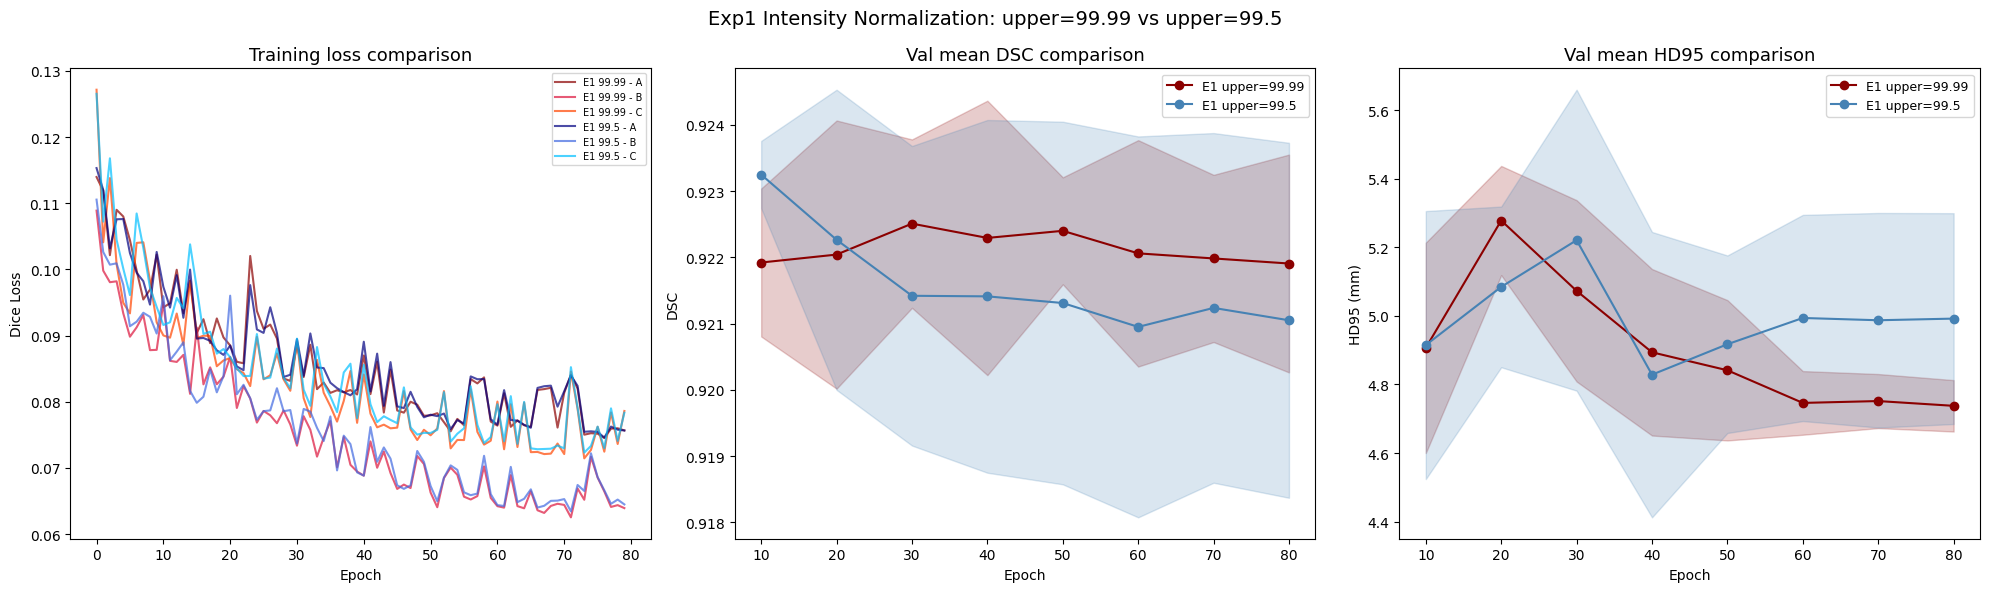

Results were saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
val_epochs = list(range(val_every, max_epochs + 1, val_every))

# Plot 1 - Training loss
axes[0].set_title("Training loss comparison", fontsize=13)
colors_99_99 = ["darkred", "crimson", "orangered"]
colors_99_5  = ["navy", "royalblue", "deepskyblue"]

for i, (cohort_name, res) in enumerate([("A", results_A), ("B", results_B), ("C", results_C)]):
    axes[0].plot(res["Exp1_IntensityNorm"]["history"]["train_loss"],
                 color=colors_99_99[i], alpha=0.7,
                 label=f"E1 99.99 - {cohort_name}")
for i, (cohort_name, res) in enumerate([("A", results_A_v2), ("B", results_B_v2), ("C", results_C_v2)]):
    axes[0].plot(res["Exp1_IntensityNorm_99_5"]["history"]["train_loss"],
                 color=colors_99_5[i], alpha=0.7,
                 label=f"E1 99.5 - {cohort_name}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Loss")
axes[0].legend(fontsize=7)

# Plot 2 - Val mean DSC
axes[1].set_title("Val mean DSC comparison", fontsize=13)
for label, res_A, res_B, res_C, exp_key, color in [
    ("E1 upper=99.99", results_A, results_B, results_C, "Exp1_IntensityNorm", "darkred"),
    ("E1 upper=99.5",  results_A_v2, results_B_v2, results_C_v2, "Exp1_IntensityNorm_99_5", "steelblue"),
]:
    scores = numpy.array([
        res_A[exp_key]["history"]["val_dice_mean"],
        res_B[exp_key]["history"]["val_dice_mean"],
        res_C[exp_key]["history"]["val_dice_mean"],
    ])
    mean_curve = numpy.mean(scores, axis=0)
    std_curve  = numpy.std(scores, axis=0)
    axes[1].plot(val_epochs, mean_curve, marker='o', color=color, label=label)
    axes[1].fill_between(val_epochs, mean_curve - std_curve,
                         mean_curve + std_curve, alpha=0.2, color=color,
                         label="_nolegend_")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("DSC")
axes[1].legend(fontsize=9)

# Plot 3 - Val mean HD95
axes[2].set_title("Val mean HD95 comparison", fontsize=13)
for label, res_A, res_B, res_C, exp_key, color in [
    ("E1 upper=99.99", results_A, results_B, results_C, "Exp1_IntensityNorm", "darkred"),
    ("E1 upper=99.5",  results_A_v2, results_B_v2, results_C_v2, "Exp1_IntensityNorm_99_5", "steelblue"),
]:
    scores = numpy.array([
        res_A[exp_key]["history"]["val_hd95_mean"],
        res_B[exp_key]["history"]["val_hd95_mean"],
        res_C[exp_key]["history"]["val_hd95_mean"],
    ])
    mean_curve = numpy.mean(scores, axis=0)
    std_curve  = numpy.std(scores, axis=0)
    axes[2].plot(val_epochs, mean_curve, marker='o', color=color, label=label)
    axes[2].fill_between(val_epochs, mean_curve - std_curve,
                         mean_curve + std_curve, alpha=0.2, color=color,
                         label="_nolegend_")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("HD95 (mm)")
axes[2].legend(fontsize=9)

plt.suptitle("Exp1 Intensity Normalization: upper=99.99 vs upper=99.5", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison_exp1_percentiles.png"), dpi=150)
plt.show()
print("Results were saved.")



## SUPPLEMENTARY C: Experiment 3 - combined preprocessing and comparison with previous experiments

This supplementary experiment combines intensity normalisation and tumour-focused sampling into a single pipeline, to test whether their effects stack. It can be skipped if the combination is not of interest.

Furthermore, this section compares all four experiments (baseline, intensity norm, tumour sampling, combined).

## Define Experiment 3: combined intensity normalization + tumor‑focused sampling

This cell creates a transform that combines:
- Intensity normalization (same as E1: upper=99.99, lower=0.5, normalize, random scale/shift)
- **Tumor‑focused sampling** using `RandCropByPosNegLabeld` with `pos=3`, `neg=1`, `num_samples=1`

**Purpose:** Force crops to contain more tumor voxels, potentially improving segmentation of small tumour sub‑regions.

The transform is stored as `train_transforms_E3`.

In [ ]:
# Experiment E3 (intensity normalization + tumor focused sampling)
train_transforms_E3 = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=roi_size,
        pos=3,
        neg=1,
        num_samples=1,
        image_key="image",
        image_threshold=0,
    ),
    SpatialPadd(keys=["image", "label"], spatial_size=roi_size),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    ScaleIntensityRangePercentilesd(
        keys="image",
        lower=0.5,
        upper=99.99,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    EnsureTyped(keys=["image", "label"], data_type="tensor", dtype=torch.float32),
])

print("Combined training transform was defined.")


## Run Experiment 3 (combined) on Cohorts A, B, C

This cell trains the model with the combined preprocessing (intensity norm + tumor sampling) on the three cohorts.

**Best mean DSC achieved:**
- **Cohort A:** 0.9245 (epoch 50)
- **Cohort B:** 0.9236 (epoch 20)
- **Cohort C:** 0.9247 (epoch 50)

Training loss initially higher than previous experiments but eventually drops to similar levels. Validation DSC and HD95 show more fluctuation, especially in Cohort C.

The combined approach achieves a mean DSC of ≈0.9243, similar to the best of previous experiments, but with slightly worse HD95 and higher variance.

In [ ]:
results_A_E3 = {}
results_B_E3 = {}
results_C_E3 = {}

for cohort_name, cohort, results_dict in [
    ("A", cohort_A, results_A_E3),
    ("B", cohort_B, results_B_E3),
    ("C", cohort_C, results_C_E3),
]:
    print(f"\nStarting Cohort {cohort_name} - E3 combined\n")
   
    train_files_cohort = build_file_list(cohort, data_dir)
   
    history, best_dice = run_experiment(
        f"Cohort{cohort_name}_Exp3_Combined",
        train_transforms_E3,
        train_files_cohort,
        val_files,
        pretrained_path,
        device
    )
    results_dict["Exp3_Combined"] = {
        "best_mean_dice": best_dice,
        "history": history
    }
    print(f"Cohort {cohort_name} completed.")

print("\nAll cohorts completed.")

In [12]:
exp_name_E3 = "Exp3_Combined"

# DSC = best mean DSC achieved by each cohort
score_A_E3 = results_A_E3[exp_name_E3]["best_mean_dice"]
score_B_E3 = results_B_E3[exp_name_E3]["best_mean_dice"]
score_C_E3 = results_C_E3[exp_name_E3]["best_mean_dice"]

# HD95 is taken at each cohort's best-DSC epoch (argmax of val_dice_mean), so the
# DSC and HD95 reported here refer to the same epoch and match the final comparison table.
best_epoch_A = int(numpy.argmax(results_A_E3[exp_name_E3]["history"]["val_dice_mean"]))
best_epoch_B = int(numpy.argmax(results_B_E3[exp_name_E3]["history"]["val_dice_mean"]))
best_epoch_C = int(numpy.argmax(results_C_E3[exp_name_E3]["history"]["val_dice_mean"]))
hd95_A_E3 = results_A_E3[exp_name_E3]["history"]["val_hd95_mean"][best_epoch_A]
hd95_B_E3 = results_B_E3[exp_name_E3]["history"]["val_hd95_mean"][best_epoch_B]
hd95_C_E3 = results_C_E3[exp_name_E3]["history"]["val_hd95_mean"][best_epoch_C]

print("\n" + "-"*100)
print("RESULTS - Exp3 Combined (Intensity Norm + Tumor Sampling)")
print("-"*100)
print(f"\n{'':30} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("-"*100)
print(f"{'Exp3 Combined DSC':<30} "
      f"{score_A_E3:>10.4f} {score_B_E3:>10.4f} {score_C_E3:>10.4f} "
      f"{numpy.mean([score_A_E3, score_B_E3, score_C_E3]):>10.4f} "
      f"{numpy.std([score_A_E3, score_B_E3, score_C_E3]):>8.4f}")

print(f"\n{'':30} {'Cohort A':>10} {'Cohort B':>10} {'Cohort C':>10} {'Mean':>10} {'Std':>8}")
print("-"*100)
print(f"{'Exp3 Combined HD95':<30} "
      f"{hd95_A_E3:>10.2f} {hd95_B_E3:>10.2f} {hd95_C_E3:>10.2f} "
      f"{numpy.mean([hd95_A_E3, hd95_B_E3, hd95_C_E3]):>10.2f} "
      f"{numpy.std([hd95_A_E3, hd95_B_E3, hd95_C_E3]):>8.2f}")

# Save E3 results
results_E3_json = {
    "Exp3_Combined": {
        "cohort_A_dsc": float(score_A_E3),
        "cohort_B_dsc": float(score_B_E3),
        "cohort_C_dsc": float(score_C_E3),
        "mean_dsc":     float(numpy.mean([score_A_E3, score_B_E3, score_C_E3])),
        "std_dsc":      float(numpy.std([score_A_E3, score_B_E3, score_C_E3])),
        "cohort_A_hd95": float(hd95_A_E3),
        "cohort_B_hd95": float(hd95_B_E3),
        "cohort_C_hd95": float(hd95_C_E3),
        "mean_hd95":    float(numpy.mean([hd95_A_E3, hd95_B_E3, hd95_C_E3])),
        "std_hd95":     float(numpy.std([hd95_A_E3, hd95_B_E3, hd95_C_E3])),
    }
}
with open(os.path.join(output_dir, "results_exp3_combined.json"), "w") as f:
    json.dump(results_E3_json, f, indent=2)

print("\nResults were saved.")



----------------------------------------------------------------------------------------------------
RESULTS - Exp3 Combined (Intensity Norm + Tumor Sampling)
----------------------------------------------------------------------------------------------------

                                 Cohort A   Cohort B   Cohort C       Mean      Std
----------------------------------------------------------------------------------------------------
Exp3 Combined DSC                  0.9245     0.9236     0.9247     0.9243   0.0005

                                 Cohort A   Cohort B   Cohort C       Mean      Std
----------------------------------------------------------------------------------------------------
Exp3 Combined HD95                   4.86       5.03       5.12       4.98     0.10

Results were saved.



## Results and comparison of all experiments

This cell tabulates the performance of Experiment 3 and compares it with Experiments 0, 1, 2.

In [ ]:
table = {
    "Exp0_Baseline":      (results_A, results_B, results_C),
    "Exp1_IntensityNorm": (results_A, results_B, results_C),
    "Exp2_TumorSampling": (results_A, results_B, results_C),
    "Exp3_Combined":      (results_A_E3, results_B_E3, results_C_E3),
}

def values_at_best_dsc(d, exp):
    h = d[exp]["history"]
    i = int(numpy.argmax(h["val_dice_mean"]))
    return h["val_dice_mean"][i], h["val_hd95_mean"][i]

print(f"{'Experiment':<28}{'Mean DSC':>18}    {'Std DSC':>18}         {'Mean HD95 (best DSC epoch)':>20}{'Std HD95':>18}")
print("-"*121)


Experiment                            Mean DSC               Std DSC         Mean HD95 (best DSC epoch)          Std HD95
-------------------------------------------------------------------------------------------------------------------------
Exp0_Baseline                           0.9231                0.0013                    4.97                       0.33
Exp1_IntensityNorm                      0.9234                0.0015                    5.02                       0.26
Exp2_TumorSampling                      0.9245                0.0009                    4.79                       0.44
Exp3_Combined                           0.9243                0.0005                    4.98                       0.17


## Final comparison: all four experiments (training loss, DSC, HD95)

This cell plots training loss, validation mean DSC, and validation mean HD95 for all four experiments (0, 1, 2, 3) with mean ± std across cohorts.

**Observations:**
- **Training loss:** All converge; Exp2 and Exp3 reach slightly lower final loss.
- **Validation DSC:** Exp2 and Exp3 plateau around 0.9245; Exp2 has the smallest confidence bands.
- **Validation HD95:** Exp2 maintains low HD95 (≈4.77 mm) with minimal fluctuation; Exp3 has higher and more variable HD95.

**Conclusion:** Tumor‑focused sampling alone (Exp2) is the best trade‑off: highest Dice, low boundary error, and excellent stability across cohorts.

Figure saved as `comparison_all_4_experiments.png`.

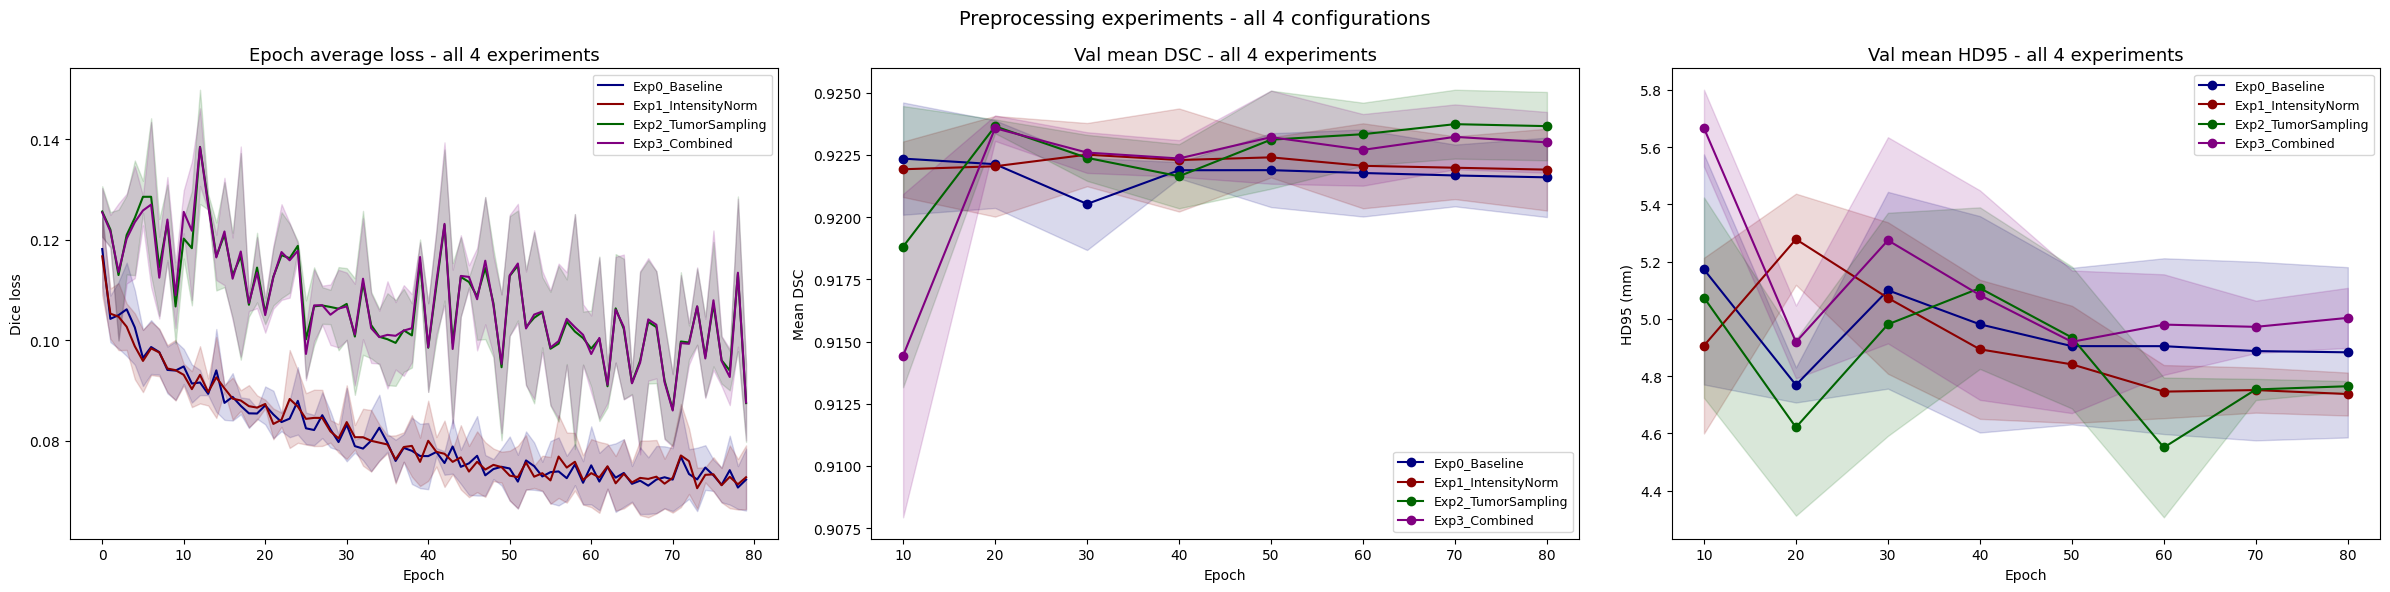

Saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
val_epochs = list(range(val_every, max_epochs + 1, val_every))

experiments_all = {
    "Exp0_Baseline":      (results_A, results_B, results_C),
    "Exp1_IntensityNorm": (results_A, results_B, results_C),
    "Exp2_TumorSampling": (results_A, results_B, results_C),
    "Exp3_Combined":      (results_A_E3, results_B_E3, results_C_E3),
}

colors_all = {
    "Exp0_Baseline":      "navy",
    "Exp1_IntensityNorm": "darkred",
    "Exp2_TumorSampling": "darkgreen",
    "Exp3_Combined":      "purple",
}

# Plot 1 - Training Loss
axes[0].set_title("Epoch average loss - all 4 experiments", fontsize=13)
for exp_name, (res_A, res_B, res_C) in experiments_all.items():
    loss_per_epoch = numpy.array([
        res_A[exp_name]["history"]["train_loss"],
        res_B[exp_name]["history"]["train_loss"],
        res_C[exp_name]["history"]["train_loss"],
    ])
    mean_loss = numpy.mean(loss_per_epoch, axis=0)
    std_loss  = numpy.std(loss_per_epoch, axis=0)
    axes[0].plot(mean_loss, color=colors_all[exp_name], label=exp_name)
    axes[0].fill_between(range(len(mean_loss)),
                         mean_loss - std_loss,
                         mean_loss + std_loss,
                         alpha=0.15, color=colors_all[exp_name],
                         label="_nolegend_")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice loss")
axes[0].legend(fontsize=9)

# Plot 2 - Val mean DSC
axes[1].set_title("Val mean DSC - all 4 experiments", fontsize=13)
for exp_name, (res_A, res_B, res_C) in experiments_all.items():
    scores_per_epoch = numpy.array([
        res_A[exp_name]["history"]["val_dice_mean"],
        res_B[exp_name]["history"]["val_dice_mean"],
        res_C[exp_name]["history"]["val_dice_mean"],
    ])
    mean_curve = numpy.mean(scores_per_epoch, axis=0)
    std_curve  = numpy.std(scores_per_epoch, axis=0)
    axes[1].plot(val_epochs, mean_curve, marker='o',
                 color=colors_all[exp_name], label=exp_name)
    axes[1].fill_between(val_epochs, mean_curve - std_curve,
                         mean_curve + std_curve, alpha=0.15,
                         color=colors_all[exp_name], label="_nolegend_")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean DSC")
axes[1].legend(fontsize=9)

# Plot 3 - Val mean HD95
axes[2].set_title("Val mean HD95 - all 4 experiments", fontsize=13)
for exp_name, (res_A, res_B, res_C) in experiments_all.items():
    scores_per_epoch = numpy.array([
        res_A[exp_name]["history"]["val_hd95_mean"],
        res_B[exp_name]["history"]["val_hd95_mean"],
        res_C[exp_name]["history"]["val_hd95_mean"],
    ])
    mean_curve = numpy.mean(scores_per_epoch, axis=0)
    std_curve  = numpy.std(scores_per_epoch, axis=0)
    axes[2].plot(val_epochs, mean_curve, marker='o',
                 color=colors_all[exp_name], label=exp_name)
    axes[2].fill_between(val_epochs, mean_curve - std_curve,
                         mean_curve + std_curve, alpha=0.15,
                         color=colors_all[exp_name], label="_nolegend_")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("HD95 (mm)")
axes[2].legend(fontsize=9)

plt.suptitle("Preprocessing experiments - all 4 configurations", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "comparison_all_4_experiments.png"), dpi=150)
plt.show()
print("Saved.")


## Preprocessing strategy - comparison and justification

Four preprocessing / sampling strategies were evaluated in **Phase 1** (preprocessing experiments, 3 cohorts x 50 validation patients). Values are reported at each run's best-DSC epoch (mean across cohorts A, B, C). The table summarises validation performance and motivates the strategy adopted for the full fine-tuning below.

| Experiment | Strategy | Val mean DSC | Val mean HD95 | Notes |
|---|---|---|---|---|
| Exp0 | Baseline (no extra preprocessing) | ≈ 0.9231 | ≈ 4.97 mm | reference pipeline |
| Exp1 | Intensity normalization (clip 0.5-99.99 pct) | ≈ 0.9234 | ≈ 5.02 mm | clipping preserved tumour signal (10/10 patients) but gave no DSC gain over baseline |
| **Exp2** | **Tumor-focused sampling (`RandCropByPosNegLabeld`, pos:neg = 3:1)** | **≈ 0.9245** | **≈ 4.79 mm** | **highest DSC and lowest boundary error; smallest cross-cohort DSC spread of the three main strategies (±0.0009)** |
| Exp3 | Combined (intensity norm + tumor sampling) | ≈ 0.9243 | ≈ 4.98 mm | no DSC gain over Exp2; higher HD95 despite the added intensity-normalisation step |

**Choice adopted: Exp2 (tumor-focused sampling).** It gave the best trade-off - the highest Dice and the lowest mean boundary error (HD95) - with the smallest cross-cohort DSC spread among the three main strategies. The combined pipeline (Exp3) did not improve DSC (0.9243 vs 0.9245) and produced a higher mean HD95 (4.98 vs 4.79 mm). Exp2 is therefore adopted as the best-performing strategy.

## Appendix - Exploratory checks

Non-essential exploratory inspections.

In [ ]:
# Inspect JSON structure to understand how training/validation patients are organized.
print(f"Type: {type(splits)}")
print(f"Keys or length: {len(splits) if isinstance(splits, list) else splits.keys()}")
print(f"\nFirst entry preview:")
print(json.dumps(splits[0] if isinstance(splits, list) else list(splits.values())[0], indent=2)[:500])

print(splits["training"][0]["image"][0])  # channel 0
print(splits["training"][0]["image"][1])  # channel 1
print(splits["training"][0]["image"][2])  # channel 2
print(splits["training"][0]["image"][3])  # channel 3
print(splits["training"][0]["label"])

## End of notebook

All experiments completed. Results are saved and can be used for further analysis or reporting.